# 02 — Single star, 10 000-row trail

Three configurations for a single bright star with no sky background or read noise:

| # | PSF | Jitter |
|---|-----|--------|
| 1 | No  | No     |
| 2 | Yes | No     |
| 3 | Yes | Yes (OU) |

Diagnostics shown for each: full trail image, column cross-sections at several rows,
and (for the jittered case) the centroid track.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from astropy.table import Table

from startrail.simulate import make_image


In [4]:
# ── Parameters ────────────────────────────────────────────────────────────────
SHAPE  = (10_000, 100)   # (rows, cols) — 10 000-row CCD readout
CX     = 50.0            # star x position (column centre)
CY     = 5_000.0         # star y position (row centre)
LENGTH = 9_800.0         # trail length in pixels (fills almost the full detector)
FWHM   = 3.0             # PSF FWHM in pixels
FLUX   = 1e8             # total trail flux (counts)
TAU    = 50.0            # OU guider timescale (pixels along trail)
JITTER = 0.5             # steady-state jitter RMS (pixels)
SEED   = 42

# Single-star table (no sky or read noise — Poisson photon noise only)
def make_single(fwhm, jitter_sigma=0.0, tau=None, seed=None):
    star = Table({
        'x':      [CX],
        'y':      [CY],
        'angle':  [0.0],
        'length': [LENGTH],
        'flux':   [FLUX],
    })
    return make_image(SHAPE, star, fwhm=fwhm,
                      sky_level=0, read_noise=0, bias=0,
                      jitter_sigma=jitter_sigma, tau=tau, seed=seed)

# Config 1: no PSF (sub-pixel FWHM ≈ delta function), no jitter
trail_1 = make_single(fwhm=0.5, seed=SEED)

# Config 2: PSF, no jitter
trail_2 = make_single(fwhm=FWHM, seed=SEED)

# Config 3: PSF, OU jitter
trail_3 = make_single(fwhm=FWHM, jitter_sigma=JITTER, tau=TAU, seed=SEED)

trails = [trail_1, trail_2, trail_3]
labels = [
    'Config 1\nNo PSF, no jitter',
    'Config 2\nPSF, no jitter',
    f'Config 3\nPSF + OU jitter\n(\u03c3={JITTER} px, \u03c4={TAU:.0f} px)',
]
print('Trails generated.')
for t, lbl in zip(trails, labels):
    print(f"  {lbl.splitlines()[0]:25s}  flux={t.sum():.3e}  peak={t.max():.3e}")


Trails generated.
  Config 1                   flux=1.000e+08  peak=1.021e+04
  Config 2                   flux=1.000e+08  peak=3.195e+03
  Config 3                   flux=1.000e+08  peak=3.766e+03


## 1. Full-trail images

Each image is 10 000 × 100 px, displayed with `aspect='auto'` so the
full readout direction is visible.  The colour scale is linear and
clipped at the 99th percentile of non-zero pixels.

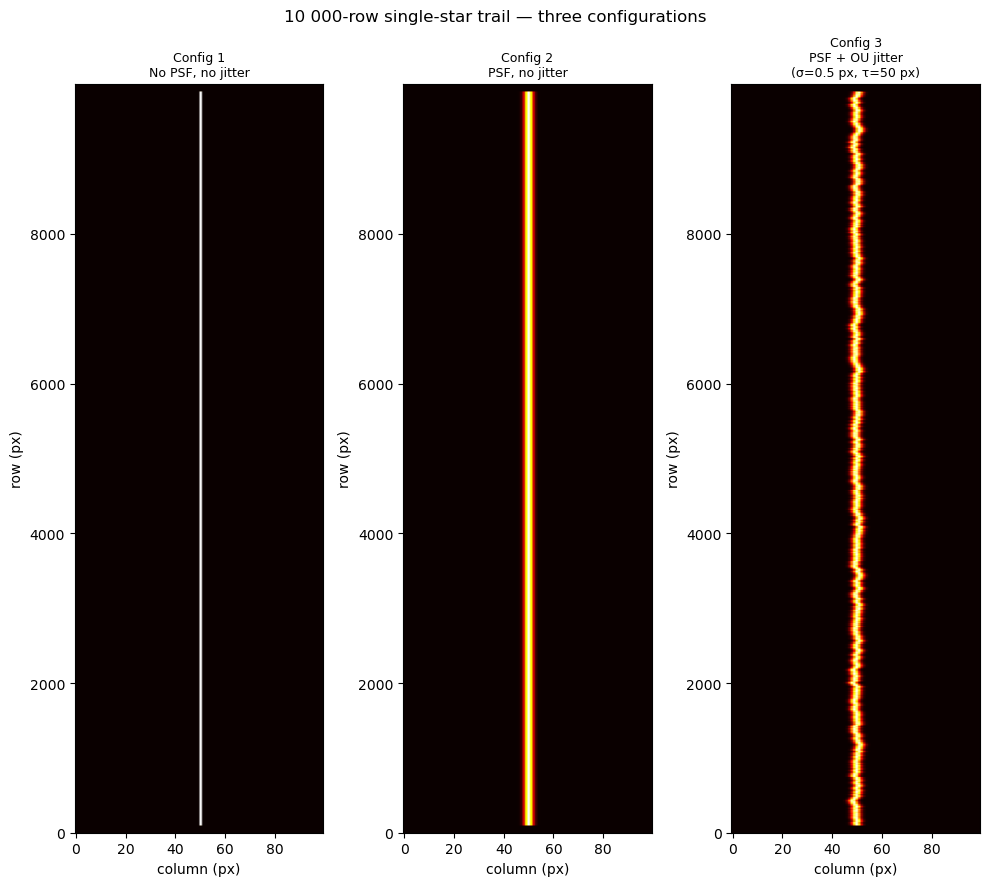

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(10, 9))

for ax, trail, label in zip(axes, trails, labels):
    nonzero = trail[trail > 0]
    vmax = np.percentile(nonzero, 99) if nonzero.size else 1.0
    ax.imshow(trail, origin='lower', cmap='hot',
              vmin=0, vmax=vmax, aspect='auto')
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('column (px)')
    ax.set_ylabel('row (px)')

plt.suptitle('10 000-row single-star trail — three configurations', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/02_full_trails.png', dpi=120)
plt.show()

## 2. Column cross-sections

Pixel value vs column at three representative rows:
near the bottom (row 600), middle (row 5 000), and near the top (row 9 400).
Config 1 should show a near-delta-function; Config 2 a stable Gaussian;
Config 3 a Gaussian whose centre shifts with the jitter.

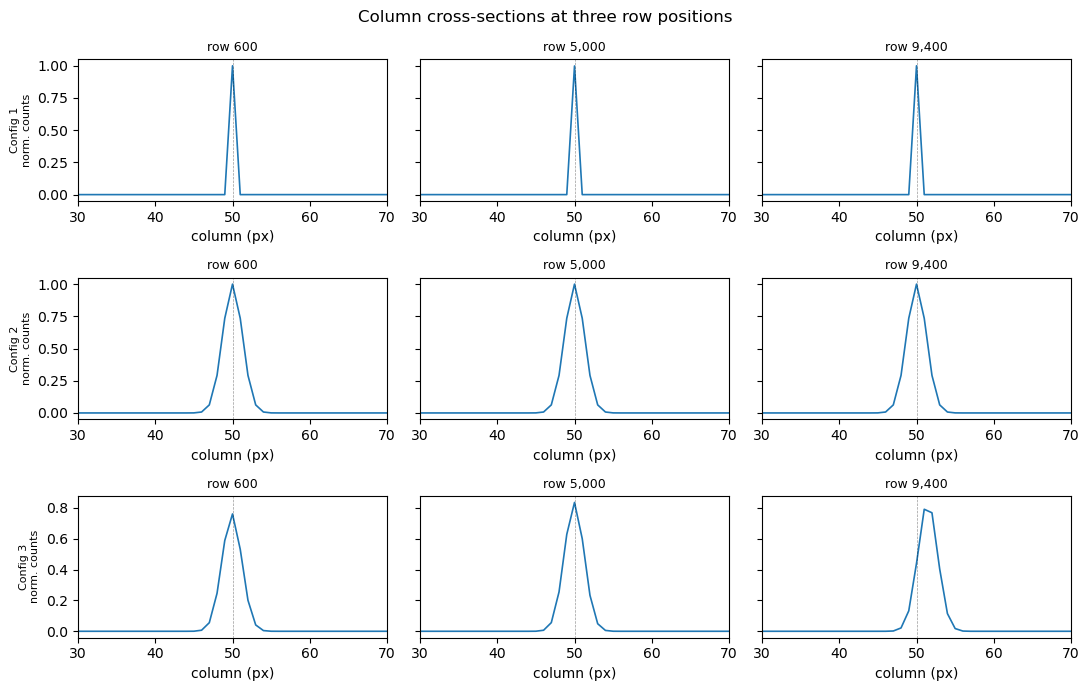

In [6]:
sample_rows = [600, 5_000, 9_400]
cols = np.arange(SHAPE[1])

fig, axes = plt.subplots(len(trails), len(sample_rows),
                         figsize=(11, 7), sharey='row')

for row_axes, trail, label in zip(axes, trails, labels):
    peak = trail.max()
    for ax, r in zip(row_axes, sample_rows):
        ax.plot(cols, trail[r] / peak, lw=1.2)
        ax.axvline(CX, color='k', lw=0.5, ls='--', alpha=0.4)
        ax.set_title(f'row {r:,}', fontsize=9)
        ax.set_xlabel('column (px)')
        ax.set_xlim(CX - 20, CX + 20)
    row_axes[0].set_ylabel(f'{label.splitlines()[0]}\nnorm. counts', fontsize=8)

plt.suptitle('Column cross-sections at three row positions', fontsize=12)
plt.tight_layout()
plt.savefig('../plots/02_cross_sections.png', dpi=120)
plt.show()

## 3. Row-summed flux profile

Total counts per row along the trail.  Should be flat (uniform flux
per readout step) for Configs 1 and 2.  Config 3 may show edge
effects where jitter pushes flux slightly outside the window.

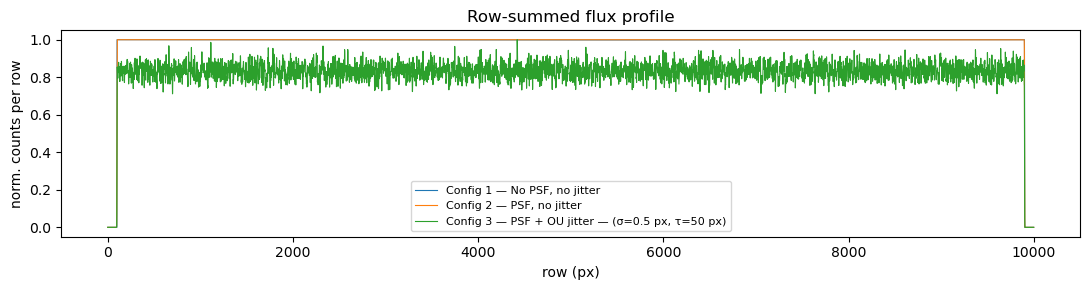

In [7]:
rows = np.arange(SHAPE[0])

fig, ax = plt.subplots(figsize=(11, 3))
for trail, label in zip(trails, labels):
    row_flux = trail.sum(axis=1)
    ax.plot(rows, row_flux / row_flux.max(), lw=0.8,
            label=label.replace('\n', ' — '))

ax.set_xlabel('row (px)')
ax.set_ylabel('norm. counts per row')
ax.set_title('Row-summed flux profile')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../plots/02_row_flux.png', dpi=120)
plt.show()

## 4. Centroid track (Config 3 — jitter)

Flux-weighted x centroid at each row, revealing the OU jitter path.
The dashed lines mark ±σ_jitter around the nominal centre.

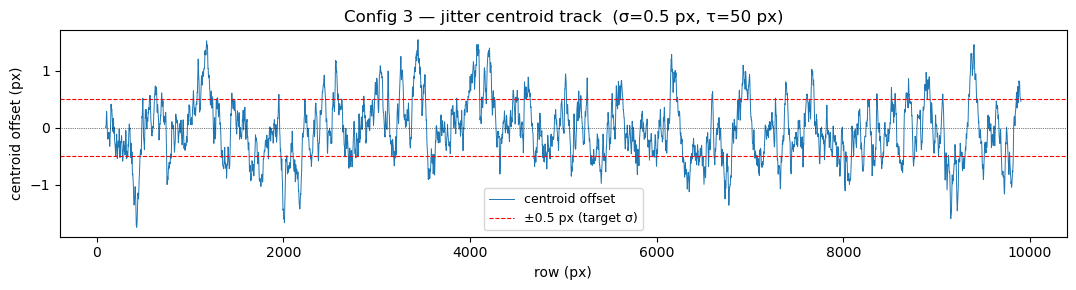

Centroid RMS offset: 0.525 px  (target σ = 0.5 px)
Centroid range:      [-1.750,  1.542] px


In [8]:
row_sum = trail_3.sum(axis=1)
# Only compute centroid where the trail has meaningful signal
trail_rows = np.where(row_sum > row_sum.max() * 1e-4)[0]

centroids = np.full(SHAPE[0], np.nan)
centroids[trail_rows] = (
    (trail_3[trail_rows] * cols[np.newaxis, :]).sum(axis=1)
    / row_sum[trail_rows]
)

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(trail_rows, centroids[trail_rows] - CX, lw=0.7, label='centroid offset')
ax.axhline( JITTER, color='r', lw=0.8, ls='--', label=f'±{JITTER} px (target σ)')
ax.axhline(-JITTER, color='r', lw=0.8, ls='--')
ax.axhline(0, color='k', lw=0.5, ls=':')
ax.set_xlabel('row (px)')
ax.set_ylabel('centroid offset (px)')
ax.set_title(f'Config 3 — jitter centroid track  (σ={JITTER} px, τ={TAU:.0f} px)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../plots/02_centroid_track.png', dpi=120)
plt.show()

rms = np.nanstd(centroids[trail_rows] - CX)
print(f'Centroid RMS offset: {rms:.3f} px  (target σ = {JITTER} px)')
print(f'Centroid range:      [{np.nanmin(centroids[trail_rows]-CX):.3f},'
      f'  {np.nanmax(centroids[trail_rows]-CX):.3f}] px')

## 5. Flux variation vs chunk size

The trail is divided into non-overlapping chunks of k rows.  For each chunk
the flux is summed over a fixed aperture centred on the nominal star position.
The standard deviation of those per-row-averaged fluxes (across all chunks) is
plotted against k, normalised by the true per-row flux `FLUX / n_trail_rows`.

A **flat plateau** at small k signals that row-to-row fluctuations are fully
correlated on the OU timescale τ — averaging more rows within a single chunk
does not help.  Beyond k ≈ τ the fluctuations average down with the expected
white-noise slope of −½.

Config 3 is regenerated here with a shorter guider timescale (τ = 50 px) so
that the correlated → uncorrelated transition falls clearly within the range of
accessible chunk sizes.

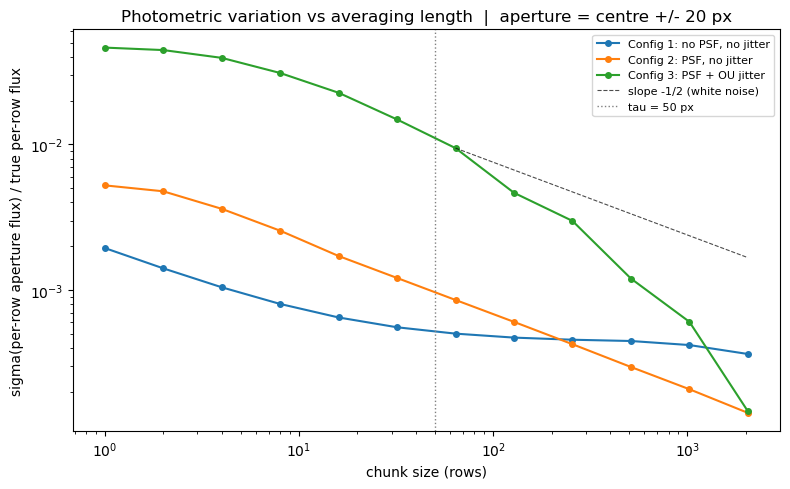

Chunk analysis summary:
  Config 1: no PSF, no jitter: k=1 -> 0.0019,  k=2048 -> 0.0004
  Config 2: PSF, no jitter: k=1 -> 0.0052,  k=2048 -> 0.0001
  Config 3: PSF + OU jitter: k=1 -> 0.0463,  k=2048 -> 0.0001


In [11]:
TAU_ANALYSIS = TAU
APERTURE_HALF_WIDTH = 20   # +/-px around nominal centre

row_start = int(CY - LENGTH / 2)
row_end   = int(CY + LENGTH / 2)
n_trail_rows = row_end - row_start
true_per_row = FLUX / n_trail_rows

chunk_sizes = 2 ** np.arange(12)
c0 = int(CX) - APERTURE_HALF_WIDTH
c1 = int(CX) + APERTURE_HALF_WIDTH + 1

configs_analysis = {
    'Config 1: no PSF, no jitter': trail_1,
    'Config 2: PSF, no jitter':    trail_2,
    'Config 3: PSF + OU jitter':   trail_3,
}

rel_stds = {}
for label, trail in configs_analysis.items():
    section = trail[row_start:row_end, c0:c1]
    stds = []
    for k in chunk_sizes:
        n_chunks = n_trail_rows // k
        if n_chunks < 4:
            stds.append(np.nan)
            continue
        blocks = section[:n_chunks * k].reshape(n_chunks, k, -1)
        chunk_flux = blocks.sum(axis=(1, 2))
        rel_std = (chunk_flux / k).std() / true_per_row
        stds.append(rel_std)
    rel_stds[label] = np.array(stds)

c3_key = f'Config 3: PSF + OU jitter'
k_trans_idx = np.searchsorted(chunk_sizes, TAU_ANALYSIS)
ref_level = rel_stds[c3_key][k_trans_idx]
k_ref = chunk_sizes[k_trans_idx:]

fig, ax = plt.subplots(figsize=(8, 5))
for label, stds in rel_stds.items():
    valid = ~np.isnan(stds)
    ax.loglog(chunk_sizes[valid], stds[valid], 'o-', ms=4, label=label)
ax.loglog(k_ref, ref_level * np.sqrt(chunk_sizes[k_trans_idx] / k_ref),
          'k--', lw=0.8, alpha=0.7, label='slope -1/2 (white noise)')
ax.axvline(TAU_ANALYSIS, color='gray', lw=1, ls=':', label=f'tau = {TAU_ANALYSIS:.0f} px')
ax.set_xlabel('chunk size (rows)')
ax.set_ylabel('sigma(per-row aperture flux) / true per-row flux')
ax.set_title('Photometric variation vs averaging length'
             f'  |  aperture = centre +/- {APERTURE_HALF_WIDTH} px')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../plots/02_chunk_analysis.png', dpi=120)
plt.show()

print('Chunk analysis summary:')
for label, stds in rel_stds.items():
    valid = ~np.isnan(stds)
    ks = chunk_sizes[valid]
    ss = stds[valid]
    print(f'  {label}: k=1 -> {ss[0]:.4f},  k={ks[-1]} -> {ss[-1]:.4f}')
